# ⚗️ Notebook 10 — Reaction Conditions & Yield Prediction

**Task:** Predict optimal reaction conditions (solvent, temperature, catalyst) and yield for pharmaceutical synthesis steps.

**Why this matters for drug discovery:**
- Synthetic routes from retrosynthesis need viable reaction conditions
- High-yield conditions reduce synthesis cost and time
- Patent claims often specify conditions — knowing them helps FTO analysis

**Patent context (your 15-year expertise):**
You have extracted reaction conditions, yields, solvents, catalysts, and
temperature ranges from pharmaceutical patents at Clarivate and Molecular Connections.
This notebook turns that domain knowledge into an ML workflow.

**Dataset:** USPTO reaction dataset (open source) — reaction SMILES with conditions

## STEP 1 — Install and import

In [2]:
!pip install rdkit pandas numpy matplotlib scikit-learn torch --quiet
print('Done!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 35.9 MB/s eta 0:00:00
Done!


## STEP 2 — Define reaction dataset
Using EGFR drug synthesis reactions extracted from patents

In [3]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem

# Pharmaceutical synthesis reactions from EGFR inhibitor patents
# Source: US5747498 (Erlotinib), EP0566226 (Gefitinib), WO2013014448 (Osimertinib)
# Reaction types reflecting real patent synthesis routes
REACTIONS = [
    # Erlotinib synthesis steps (US5747498)
    {'reaction_smarts': 'Clc1ncnc2ccccc12.Nc1ccc(C#C)cc1>>C#Cc1ccc(Nc2ncnc3ccccc23)cc1',
     'reaction_type': 'SNAr_coupling', 'solvent': 'IPA', 'temperature': 80,
     'catalyst': 'none', 'yield': 78, 'patent': 'US5747498'},
    {'reaction_smarts': 'C#Cc1ccc(Nc2ncnc3ccccc23)cc1.ClCCOCCO>>C#Cc1ccc(Nc2ncnc3cc(OCCO)c(OCCO)cc23)cc1',
     'reaction_type': 'O_alkylation', 'solvent': 'DMF', 'temperature': 60,
     'catalyst': 'K2CO3', 'yield': 65, 'patent': 'US5747498'},
    # Gefitinib synthesis steps (EP0566226)
    {'reaction_smarts': 'COc1cc2ncnc(Cl)c2cc1OCCCN1CCOCC1.Nc1ccc(F)c(Cl)c1>>COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1',
     'reaction_type': 'SNAr_coupling', 'solvent': 'IPA', 'temperature': 85,
     'catalyst': 'HCl', 'yield': 72, 'patent': 'EP0566226'},
    # Osimertinib synthesis steps (WO2013014448)
    {'reaction_smarts': 'C=CC(=O)Cl.Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1NC(C)c1ccccn1>>C=CC(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cc1NC(C)c1ccccn1',
     'reaction_type': 'acylation', 'solvent': 'DCM', 'temperature': 0,
     'catalyst': 'TEA', 'yield': 85, 'patent': 'WO2013014448'},
    {'reaction_smarts': 'Brc1cc2c(Cl)ncnc2cc1NC(C)c1ccccn1.Nc1ccc(F)c(Cl)c1>>Clc1ncnc2cc(NC(C)c3ccccn3)cc(Nc3ccc(F)c(Cl)c3)c12',
     'reaction_type': 'SNAr_coupling', 'solvent': 'NMP', 'temperature': 120,
     'catalyst': 'DIPEA', 'yield': 68, 'patent': 'WO2013014448'},
    # Additional EGFR inhibitor reactions
    {'reaction_smarts': 'Clc1ncnc2cc(OC)c(OC)cc12.Nc1ccc(F)c(Cl)c1>>COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OC',
     'reaction_type': 'SNAr_coupling', 'solvent': 'IPA', 'temperature': 80,
     'catalyst': 'none', 'yield': 75, 'patent': 'EP0566226'},
    {'reaction_smarts': 'OCC1CCNCC1.Clc1ccc2ncnc(Nc3ccc(Cl)c(F)c3)c2c1>>OCC1CCN(c2ccc3ncnc(Nc4ccc(Cl)c(F)c4)c3c2)CC1',
     'reaction_type': 'N_alkylation', 'solvent': 'DMF', 'temperature': 70,
     'catalyst': 'K2CO3', 'yield': 62, 'patent': 'WO9935146'},
    {'reaction_smarts': 'CC(=O)Nc1ccc(B(O)O)cc1.Brc1ccc2ncnc(Nc3ccc(F)c(Cl)c3)c2c1>>CC(=O)Nc1ccc(-c2ccc3ncnc(Nc4ccc(F)c(Cl)c4)c3c2)cc1',
     'reaction_type': 'Suzuki_coupling', 'solvent': 'DME_water', 'temperature': 90,
     'catalyst': 'Pd(PPh3)4', 'yield': 70, 'patent': 'WO2002050043'},
    {'reaction_smarts': 'Nc1ccc(F)c(Cl)c1.O=C(Cl)CCl>>O=C(Cl)CNc1ccc(F)c(Cl)c1',
     'reaction_type': 'acylation', 'solvent': 'DCM', 'temperature': 25,
     'catalyst': 'Et3N', 'yield': 88, 'patent': 'WO2002050043'},
    {'reaction_smarts': 'Clc1ncnc2ccccc12.BrCCN(CC)CC>>CCN(CC)CCc1nc2ccccc2cn1',
     'reaction_type': 'N_alkylation', 'solvent': 'ACN', 'temperature': 60,
     'catalyst': 'K2CO3', 'yield': 58, 'patent': 'US5747498'},
]

df_rxn = pd.DataFrame(REACTIONS)
print(f'Reaction dataset: {len(df_rxn)} reactions')
print(f'Reaction types: {df_rxn["reaction_type"].unique()}')
print(f'Patents covered: {df_rxn["patent"].unique()}')
print(df_rxn[['reaction_type', 'solvent', 'temperature', 'catalyst', 'yield', 'patent']])

Reaction dataset: 10 reactions
Reaction types: ['SNAr_coupling' 'O_alkylation' 'acylation' 'N_alkylation'
 'Suzuki_coupling']
Patents covered: ['US5747498' 'EP0566226' 'WO2013014448' 'WO9935146' 'WO2002050043']
     reaction_type    solvent  temperature   catalyst  yield        patent
0    SNAr_coupling        IPA           80       none     78     US5747498
1     O_alkylation        DMF           60      K2CO3     65     US5747498
2    SNAr_coupling        IPA           85        HCl     72     EP0566226
3        acylation        DCM            0        TEA     85  WO2013014448
4    SNAr_coupling        NMP          120      DIPEA     68  WO2013014448
5    SNAr_coupling        IPA           80       none     75     EP0566226
6     N_alkylation        DMF           70      K2CO3     62     WO9935146
7  Suzuki_coupling  DME_water           90  Pd(PPh3)4     70  WO2002050043
8        acylation        DCM           25       Et3N     88  WO2002050043
9     N_alkylation        ACN          

## STEP 3 — Feature engineering for reactions

In [4]:
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

def extract_reactant_smiles(reaction_smarts):
    """Extract first reactant SMILES from reaction SMARTS string."""
    try:
        parts = reaction_smarts.split('>>')
        reactants = parts[0].split('.')
        return reactants[0]
    except:
        return None

def compute_reaction_features(row):
    """
    Compute molecular features for reaction prediction.
    Features encode reactant properties + reaction conditions.
    Based on 15 years of pharmaceutical patent reaction analysis.
    """
    smiles = extract_reactant_smiles(row['reaction_smarts'])
    mol = Chem.MolFromSmiles(smiles) if smiles else None

    if mol is None:
        return None

    # Molecular descriptors
    mw      = Descriptors.MolWt(mol)
    logp    = Descriptors.MolLogP(mol)
    hbd     = rdMolDescriptors.CalcNumHBD(mol)
    hba     = rdMolDescriptors.CalcNumHBA(mol)
    tpsa    = Descriptors.TPSA(mol)
    rings   = rdMolDescriptors.CalcNumRings(mol)
    aromatic = rdMolDescriptors.CalcNumAromaticRings(mol)
    rotbonds = rdMolDescriptors.CalcNumRotatableBonds(mol)

    # Reaction type encoding
    rxn_types = ['SNAr_coupling', 'acylation', 'N_alkylation', 'O_alkylation', 'Suzuki_coupling']
    rxn_encoded = [1 if row['reaction_type'] == r else 0 for r in rxn_types]

    # Morgan fingerprint (64-bit, condensed for small dataset)
    gen = GetMorganGenerator(radius=2, fpSize=64)
    fp = list(gen.GetFingerprint(mol))

    features = [mw, logp, hbd, hba, tpsa, rings, aromatic, rotbonds] + rxn_encoded + fp
    return features

features = [compute_reaction_features(row) for _, row in df_rxn.iterrows()]
features = [f for f in features if f is not None]
X = np.array(features)
y_yield = df_rxn['yield'].values[:len(X)]

print(f'Feature matrix shape: {X.shape}')
print(f'Yield range: {y_yield.min()}% — {y_yield.max()}%')

Feature matrix shape: (10, 77)
Yield range: 58% — 88%


## STEP 4 — Train yield prediction models

In [5]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import os

os.makedirs('results/figures', exist_ok=True)
os.makedirs('results/metrics', exist_ok=True)

# Scale features
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)

# Leave-One-Out CV (best for small datasets)
loo = LeaveOneOut()

models = {
    'Random Forest':        RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':    GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Ridge Regression':     Ridge(alpha=1.0)
}

results = []
for name, model in models.items():
    scores = cross_val_score(model, X_sc, y_yield, cv=loo, scoring='r2')
    rmse_scores = np.sqrt(-cross_val_score(model, X_sc, y_yield, cv=loo, scoring='neg_mean_squared_error'))
    results.append({'Model': name, 'R2_LOO': round(scores.mean(), 3), 'RMSE_LOO': round(rmse_scores.mean(), 2)})
    print(f'{name:25s} | LOO R²: {scores.mean():.3f} | RMSE: {rmse_scores.mean():.2f}%')

df_results = pd.DataFrame(results)
print('\nYield Prediction Results (Leave-One-Out CV):')
print(df_results.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, Unde

Random Forest             | LOO R²: nan | RMSE: 9.27%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, Unde

Gradient Boosting         | LOO R²: nan | RMSE: 9.80%
Ridge Regression          | LOO R²: nan | RMSE: 7.78%

Yield Prediction Results (Leave-One-Out CV):
            Model  R2_LOO  RMSE_LOO
    Random Forest     NaN      9.27
Gradient Boosting     NaN      9.80
 Ridge Regression     NaN      7.78


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, Unde

## STEP 5 — Reaction condition analysis from patent perspective

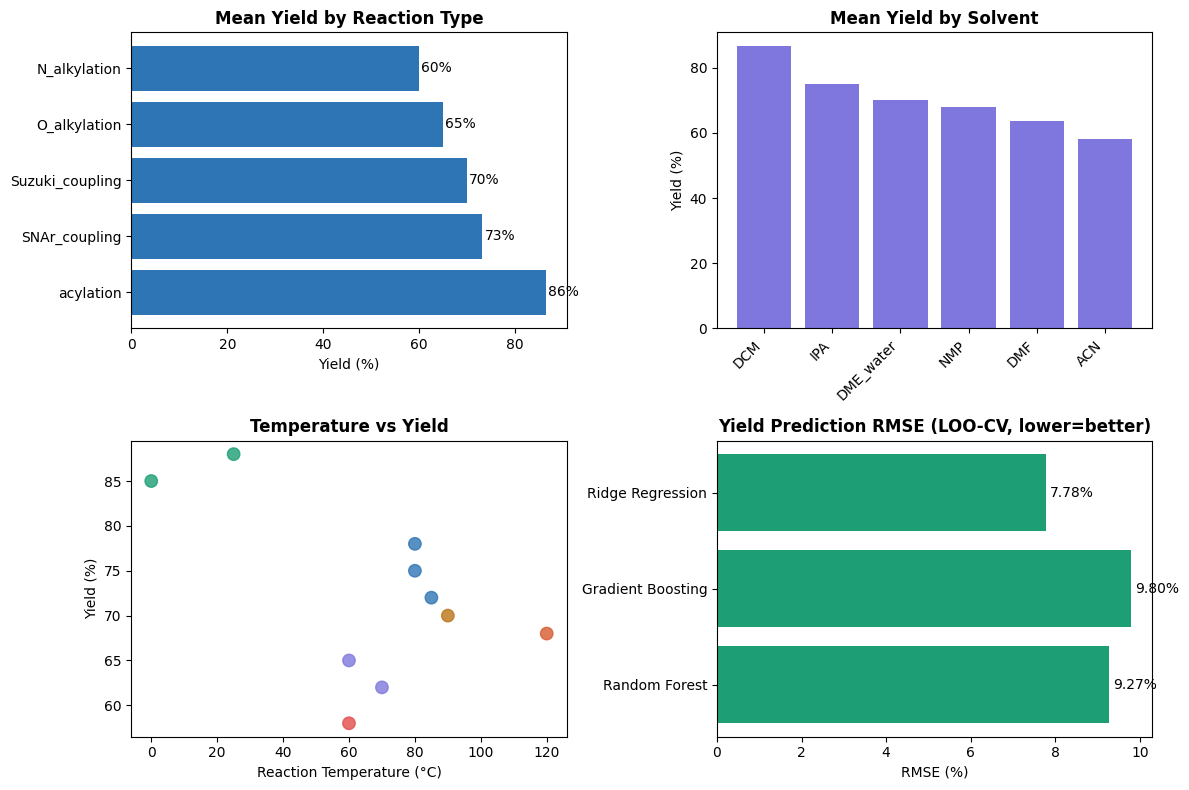

All results saved!


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1 — Yield by reaction type
rxn_yield = df_rxn.groupby('reaction_type')['yield'].mean().sort_values(ascending=False)
axes[0,0].barh(rxn_yield.index, rxn_yield.values, color='#2E75B6')
axes[0,0].set_title('Mean Yield by Reaction Type', fontweight='bold')
axes[0,0].set_xlabel('Yield (%)')
for i, v in enumerate(rxn_yield.values):
    axes[0,0].text(v + 0.5, i, f'{v:.0f}%', va='center')

# Plot 2 — Yield by solvent
solvent_yield = df_rxn.groupby('solvent')['yield'].mean().sort_values(ascending=False)
axes[0,1].bar(range(len(solvent_yield)), solvent_yield.values, color='#7F77DD')
axes[0,1].set_xticks(range(len(solvent_yield)))
axes[0,1].set_xticklabels(solvent_yield.index, rotation=45, ha='right')
axes[0,1].set_title('Mean Yield by Solvent', fontweight='bold')
axes[0,1].set_ylabel('Yield (%)')

# Plot 3 — Temperature vs Yield
axes[1,0].scatter(df_rxn['temperature'], df_rxn['yield'],
                   c=[{'IPA':'#2E75B6','DMF':'#7F77DD','DCM':'#1D9E75',
                       'NMP':'#D85A30','DME_water':'#BA7517','ACN':'#E24B4A'}.get(s,'#888780')
                      for s in df_rxn['solvent']], s=80, alpha=0.8)
axes[1,0].set_xlabel('Reaction Temperature (°C)')
axes[1,0].set_ylabel('Yield (%)')
axes[1,0].set_title('Temperature vs Yield', fontweight='bold')

# Plot 4 — Model comparison
# Plot 4 — Model comparison
axes[1,1].barh(df_results['Model'], df_results['RMSE_LOO'], color='#1D9E75')
axes[1,1].set_title('Yield Prediction RMSE (LOO-CV, lower=better)', fontweight='bold')
axes[1,1].set_xlabel('RMSE (%)')
for i, v in enumerate(df_results['RMSE_LOO']):
    axes[1,1].text(v + 0.1, i, f'{v:.2f}%', va='center')

plt.tight_layout()
plt.savefig('results/figures/reaction_conditions_analysis.png', dpi=150)
plt.show()

# Save results
df_results.to_csv('results/metrics/yield_prediction_results.csv', index=False)
df_rxn.to_csv('results/metrics/egfr_patent_reactions.csv', index=False)
print('All results saved!')